C:\Users\NAVANEETH SUNDAR\AppData\Local\Programs\Python\Python314\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


Sequences Downloaded

  Species  Length  Identity_to_Human(%)
0   Human     110                100.00
1   Mouse      89                 30.91
2     Rat      18                 11.82
3     Cow     105                 80.00
4     Pig     108                 86.36


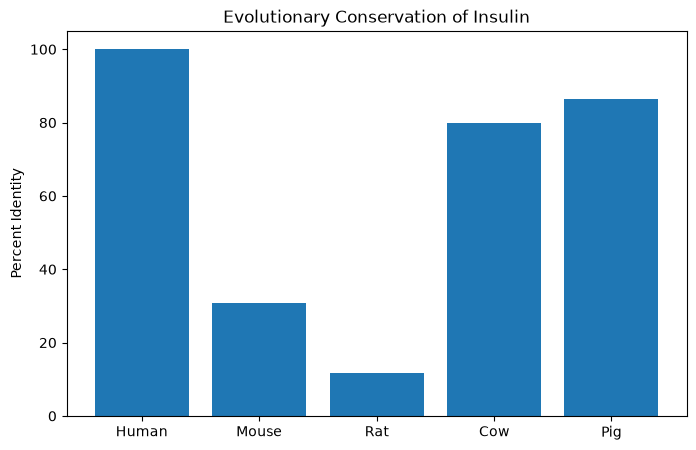


Human vs Mouse Alignment

MA-LWM--RLLPLLALLA-L--W------GP--------DPAAAFVNQHLC--GSHLVEA-LY--L----V-----CGE--RGFFYTPKT--R--R-E--AEDLQVGQVELGGGPGA-G-SLQPLA---LEGSLQKRGIVEQ--C-CTS---ICSLYQLENYCN-
   |    |  |       |  |      |         |    |    |   || |    |   |    |     |    |  |       |  | |  |      ||         | |  |     |  |           | |     | |  |       
--VL--TFR--P------VLSPWTMSDDNG-SGNNCTTND----F----L-LNGS-L---GL-GGLLLLLVIILFIC--LCR--F-----SQRVKRLERNA------QV--------SGRS--P--TMHL--S---------SSCQC--PVVI-S--Q------T
  Score=34



In [1]:
from Bio import Entrez, SeqIO, pairwise2
from Bio.pairwise2 import format_alignment
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

# -------------------------
# NCBI SETTINGS
# -------------------------
Entrez.email = "navaneethsundar2007@gmail.com"

# Protein accession numbers
proteins = {
    "Human": "AAA59172.1",
    "Mouse": "AAA37273.1",
    "Rat": "AAA41218.1",
    "Cow": "P01317",
    "Pig": "P01315"
}

# -------------------------
# FETCH SEQUENCES
# -------------------------
seqs = {}

for species, acc in proteins.items():
    handle = Entrez.efetch(
        db="protein",
        id=acc,
        rettype="fasta",
        retmode="text"
    )

    record = SeqIO.read(handle, "fasta")
    seqs[species] = str(record.seq)

print("Sequences Downloaded\n")

# -------------------------
# COMPARE WITH HUMAN
# -------------------------
human = seqs["Human"]

results = []

for species, seq in seqs.items():

    alignment = pairwise2.align.globalxx(
        human,
        seq
    )[0]

    matches = alignment.score

    identity = (
        matches /
        max(len(human), len(seq))
    ) * 100

    results.append(
        [species,
         len(seq),
         round(identity,2)]
    )

# -------------------------
# TABLE
# -------------------------
df = pd.DataFrame(
    results,
    columns=[
        "Species",
        "Length",
        "Identity_to_Human(%)"
    ]
)

print(df)

# -------------------------
# GRAPH
# -------------------------
plt.figure(figsize=(8,5))
plt.bar(
    df["Species"],
    df["Identity_to_Human(%)"]
)
plt.ylabel("Percent Identity")
plt.title(
    "Evolutionary Conservation of Insulin"
)
plt.show()

# -------------------------
# BEST ALIGNMENT EXAMPLE
# -------------------------
print("\nHuman vs Mouse Alignment\n")

alignment = pairwise2.align.globalxx(
    seqs["Human"],
    seqs["Mouse"]
)[0]

print(
    format_alignment(
        *alignment
    )[:1000]
)